### Import Libraries

In [10]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller

### Load dataset

In [11]:
df = pd.read_csv("../data/clean_weather.csv")

df["time"] = pd.to_datetime(df["time"])

df.head()

,time,temperature_max,temperature_min,precipitation,wind_speed,wind_direction,cloud_cover,dew_point,humidity,temperature_mean,sunrise,sunset,pressure
0,2015-01-01,21.3,12.0,0.0,8.9,66,83,10.0,68,16.3,2015-01-01 07:13:00,2015-01-01 17:35:00,991.6
1,2015-01-02,17.2,14.2,4.2,11.2,73,98,12.4,83,15.3,2015-01-02 07:14:00,2015-01-02 17:35:00,992.5
2,2015-01-03,17.9,14.0,0.1,9.0,312,97,12.8,84,15.6,2015-01-03 07:14:00,2015-01-03 17:36:00,992.0
3,2015-01-04,19.1,10.9,0.0,13.5,317,35,10.3,78,14.4,2015-01-04 07:14:00,2015-01-04 17:37:00,993.7
4,2015-01-05,20.7,9.6,0.0,27.0,302,0,9.2,74,14.3,2015-01-05 07:14:00,2015-01-05 17:38:00,990.8


### Basis Information

In [12]:
print("=" * 50)
print("Dataset Shape")
print("=" * 50)
print(df.shape)

print("\n")

print("=" * 50)
print("Columns")
print("=" * 50)
print(df.columns)

print("\n")

print("=" * 50)
print("Data Types")
print("=" * 50)
print(df.dtypes)

Dataset Shape
(4230, 13)


Columns
Index(['time', 'temperature_max', 'temperature_min', 'precipitation',
       'wind_speed', 'wind_direction', 'cloud_cover', 'dew_point', 'humidity',
       'temperature_mean', 'sunrise', 'sunset', 'pressure'],
      dtype='object')


Data Types
time                datetime64[ns]
temperature_max            float64
temperature_min            float64
precipitation              float64
wind_speed                 float64
wind_direction               int64
cloud_cover                  int64
dew_point                  float64
humidity                     int64
temperature_mean           float64
sunrise                     object
sunset                      object
pressure                   float64
dtype: object


### Missing Values

In [13]:
print(df.isnull().sum())

time                0
temperature_max     0
temperature_min     0
precipitation       0
wind_speed          0
wind_direction      0
cloud_cover         0
dew_point           0
humidity            0
temperature_mean    0
sunrise             0
sunset              0
pressure            0
dtype: int64


In [14]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
time,4230,2020-10-15 11:59:59.999999744,2015-01-01 00:00:00,2017-11-23 06:00:00,2020-10-15 12:00:00,2023-09-07 18:00:00,2026-07-31 00:00:00,NaN
temperature_max,4230.0,30.497991,12.8,25.3,31.6,35.1,46.0,6.788543
temperature_min,4230.0,19.534681,2.0,13.1,21.3,25.8,34.5,7.216258
precipitation,4230.0,2.07,0.0,0.0,0.0,0.8,122.7,6.667991
wind_speed,4230.0,14.738061,3.4,10.8,14.0,17.8,36.1,5.004622
wind_direction,4230.0,218.292908,0.0,113.0,276.0,303.0,359.0,102.689582
cloud_cover,4230.0,32.338534,0.0,4.0,22.0,54.0,100.0,31.563353
dew_point,4230.0,15.328936,-3.6,9.6,14.1,22.4,26.8,6.883618
humidity,4230.0,61.827187,10.0,50.0,65.0,77.0,96.0,18.643883
temperature_mean,4230.0,24.686478,6.7,18.7,26.8,29.9,39.2,6.992131


### Plots

In [15]:
weather_columns = [
    "temperature_max",
    "temperature_min",
    "temperature_mean",
    "humidity",
    "precipitation",
    "wind_speed",
    "wind_direction",
    "pressure",
    "cloud_cover",
    "dew_point",
]

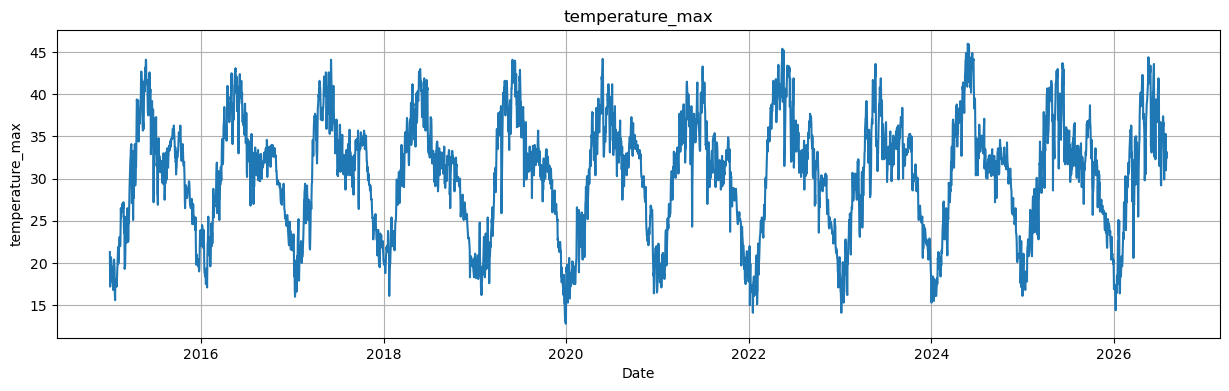

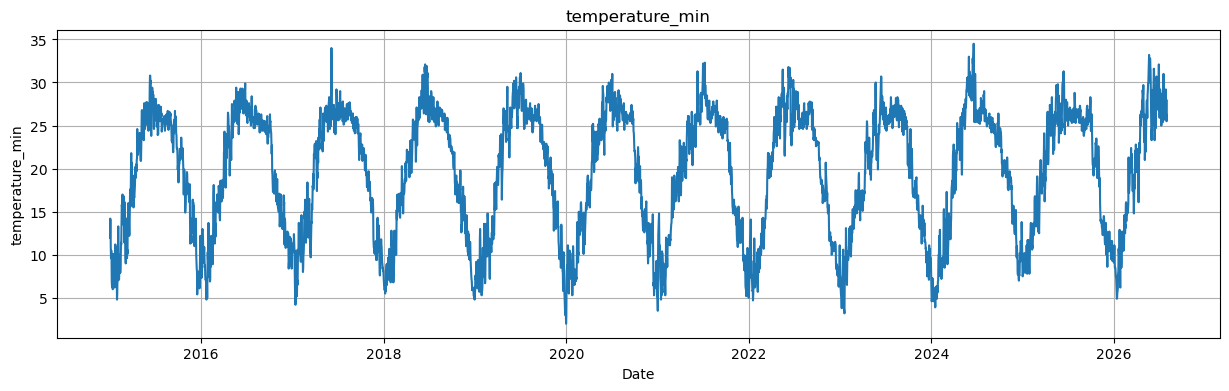

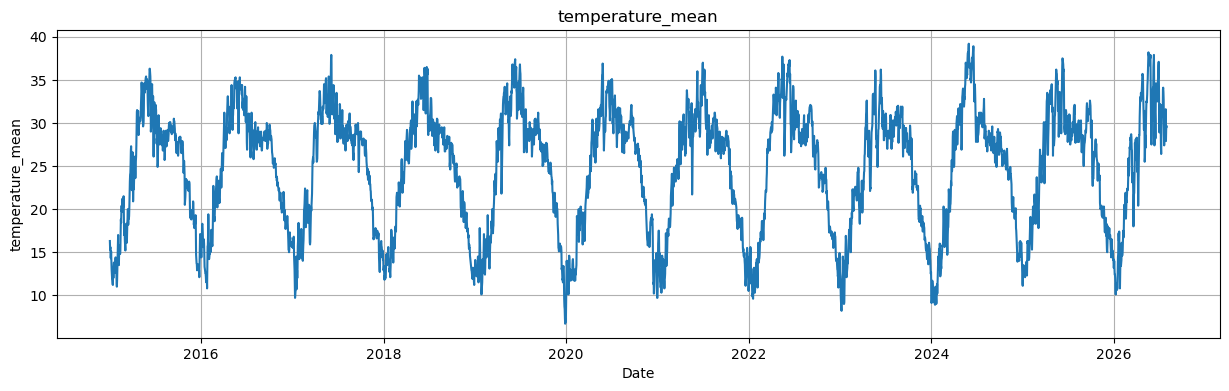

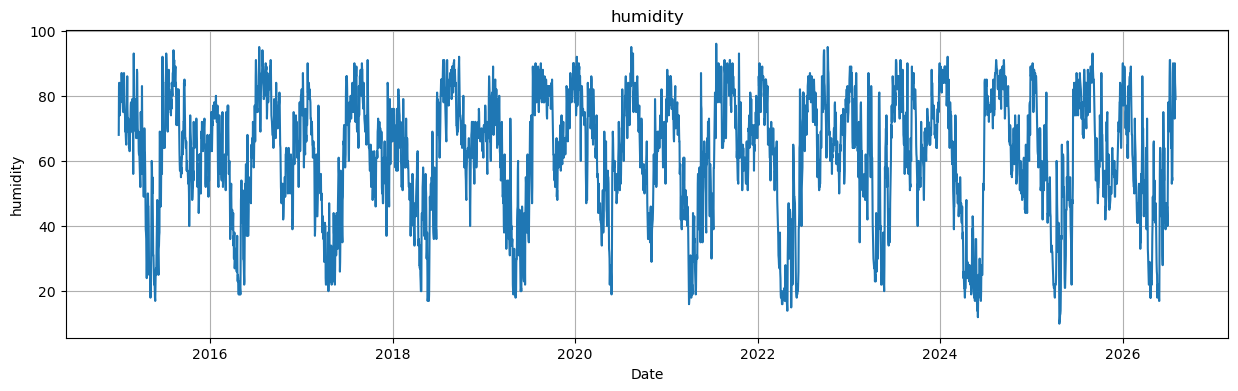

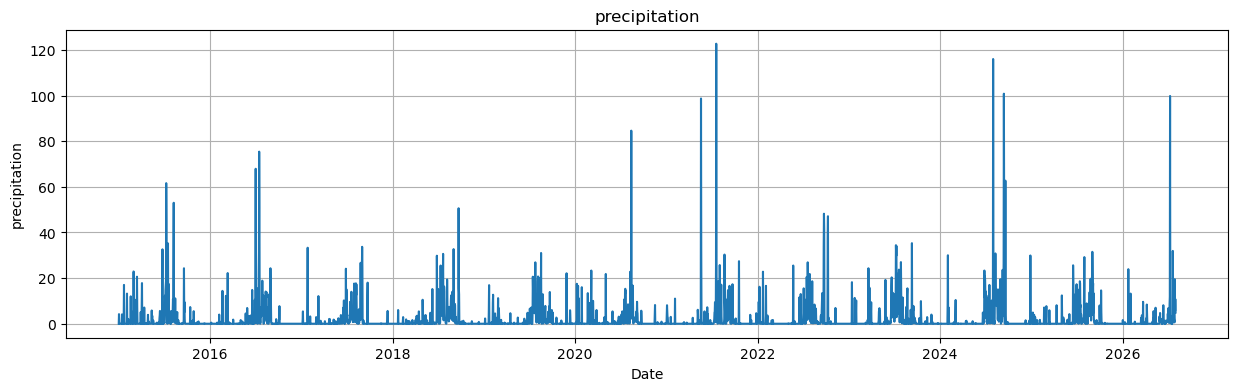

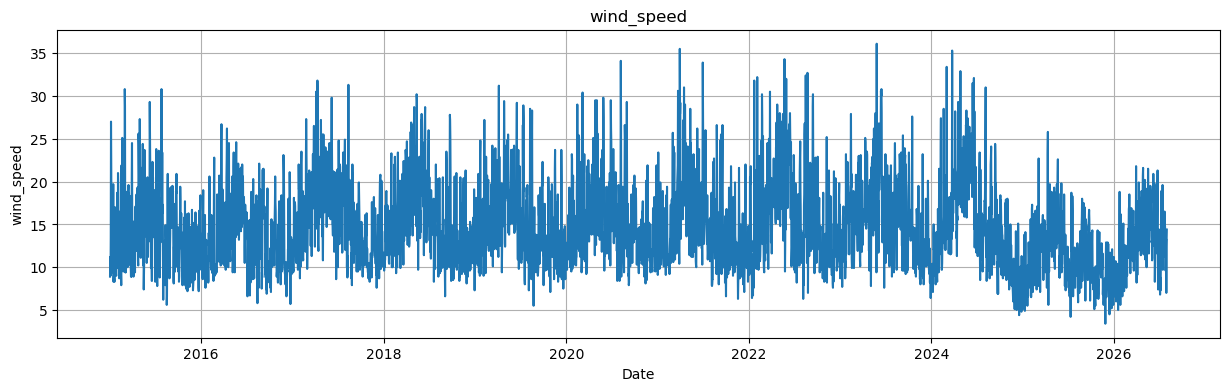

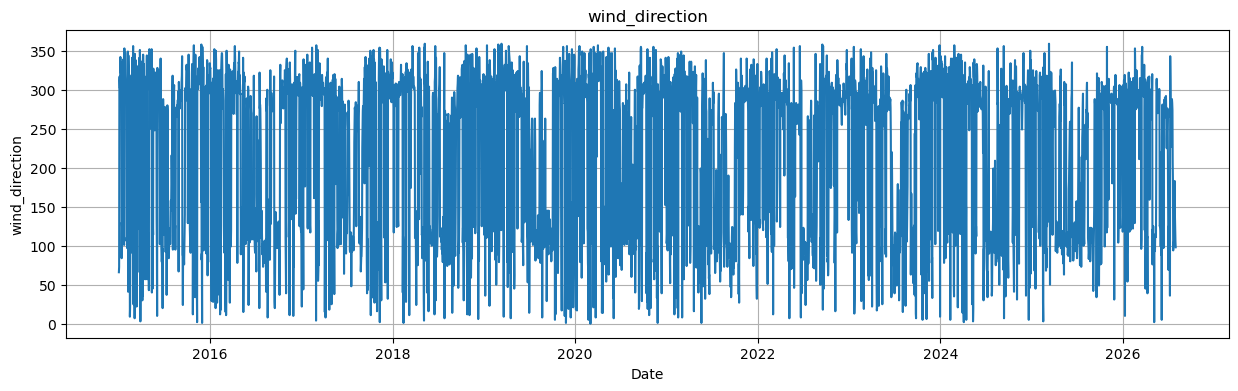

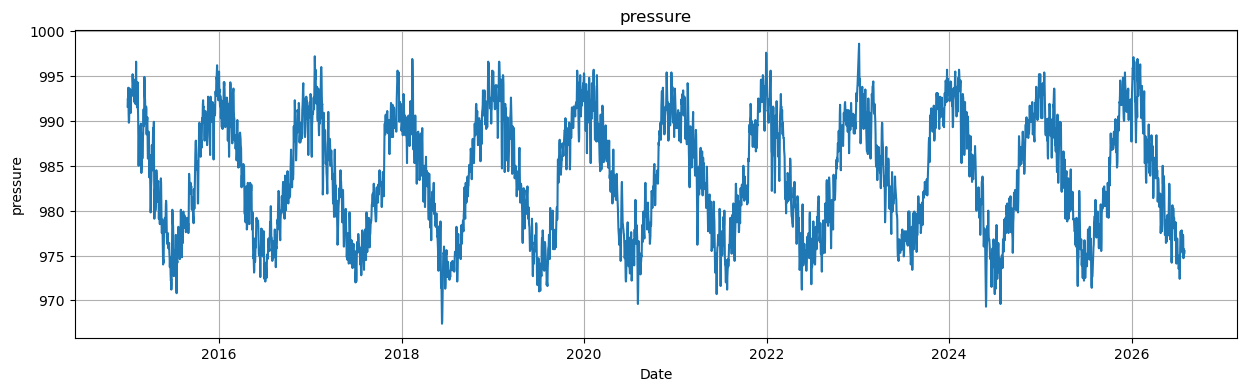

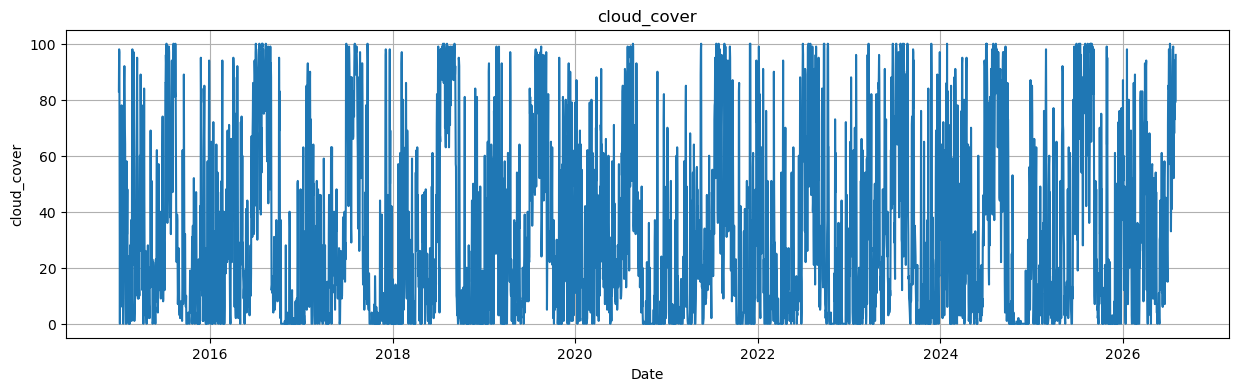

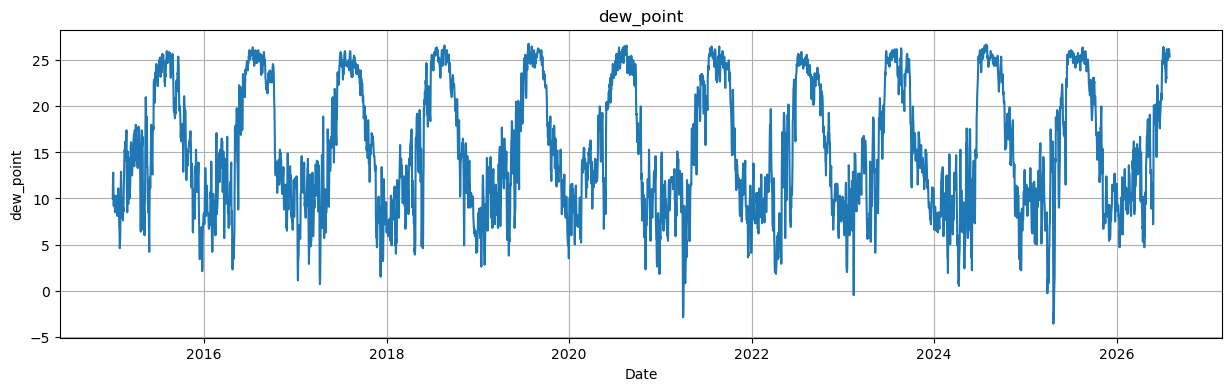

In [16]:
for col in weather_columns:

    plt.figure(figsize=(15,4))

    plt.plot(df["time"], df[col])

    plt.title(col)

    plt.xlabel("Date")

    plt.ylabel(col)

    plt.grid(True)

    plt.show()

### Stationarity Test

In [18]:
def adf_test(series):

    result = adfuller(series)

    print("ADF Statistic :", result[0])

    print("P-value       :", result[1])

    print()

    if result[1] < 0.05:

        print("Stationary")

    else:

        print("Not Stationary")

In [19]:
for col in weather_columns:

    print("=" * 60)

    print(col)

    print("=" * 60)

    adf_test(df[col])

    print()

temperature_max
ADF Statistic : -5.661232048138545
P-value       : 9.369736049840178e-07

Stationary

temperature_min
ADF Statistic : -4.9643363708107255
P-value       : 2.60973123078402e-05

Stationary

temperature_mean
ADF Statistic : -5.425091856703709
P-value       : 2.9995128785381566e-06

Stationary

humidity
ADF Statistic : -6.46041690166658
P-value       : 1.4479211828317775e-08

Stationary

precipitation
ADF Statistic : -10.048860569168426
P-value       : 1.4301842992050446e-17

Stationary

wind_speed
ADF Statistic : -4.924621866967978
P-value       : 3.1223386011984796e-05

Stationary

wind_direction
ADF Statistic : -12.941390481749881
P-value       : 3.528569657978965e-24

Stationary

pressure
ADF Statistic : -3.5646571179364073
P-value       : 0.006473786833194456

Stationary

cloud_cover
ADF Statistic : -8.39345180540389
P-value       : 2.3329612238300184e-13

Stationary

dew_point
ADF Statistic : -4.448587133840585
P-value       : 0.00024326667411804831

Stationary

